In [3]:
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest

In [5]:
df=pd.read_csv("C:\\Users\\hp\\Downloads\\TestAnomalyUnlabled.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      1000 non-null   str    
 1   temperature_c  1000 non-null   float64
 2   humidity_pct   1000 non-null   float64
 3   pressure_hpa   1000 non-null   float64
dtypes: float64(3), str(1)
memory usage: 31.4 KB


In [6]:
df=df.dropna()  

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      1000 non-null   str    
 1   temperature_c  1000 non-null   float64
 2   humidity_pct   1000 non-null   float64
 3   pressure_hpa   1000 non-null   float64
dtypes: float64(3), str(1)
memory usage: 31.4 KB


In [8]:
anomaly_inputs=['temperature_c','humidity_pct']

In [9]:
model_IF=IsolationForest(contamination=0.1,random_state=42)

In [10]:
model_IF.fit(df[anomaly_inputs])

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [11]:
df['anomaly_scores']=model_IF.decision_function(df[anomaly_inputs])

In [12]:
df['anomaly']=model_IF.predict(df[anomaly_inputs])

In [13]:
df.loc[:,['temperature_c','humidity_pct','anomaly_scores','anomaly'   ]]

,temperature_c,humidity_pct,anomaly_scores,anomaly
0,29.054849,67.952574,0.014943,1
1,28.852943,67.316221,0.003444,1
2,29.215345,67.467761,0.018826,1
3,29.289658,68.206237,0.009007,1
4,28.809215,67.601390,0.009676,1
...,...,...,...,...
995,31.184471,63.011156,0.080153,1
996,31.257329,62.944818,0.062078,1
997,31.138877,62.634105,0.081307,1
998,31.137804,62.289677,0.064217,1


In [14]:
print(df["temperature_c"].min())
print(df["temperature_c"].max())

print(df["humidity_pct"].min())
print(df["humidity_pct"].max())

26.44586489173849
48.31487933637854
28.276801231091905
75.4789281497209


In [26]:
def outlier_plot( data,outlier_method_name, x_var,y_var,
            xaxis_limits=[25,50],yaxis_limits=[25,100]):
    print(f'outlier method:{outlier_method_name}')

    method=f'{outlier_method_name}_anomaly'
    print(f"number of anomalous values {len(data[data['anomaly']==-1])}")
    print(f"number of non anomalous values {len(data[data['anomaly']==1])}")
    print(f'total number of values:{len(data)}')


    g=sns.FacetGrid(data,col='anomaly',col_order=[1,-1],height=4,hue='anomaly',hue_order=[1,-1])
    g.map(sns.scatterplot,x_var,y_var)
    g.figure.suptitle(f"outlier method :{outlier_method_name}"
                      ,y=1.10,
                      fontweight='bold')
    g.set(xlim=xaxis_limits,ylim=yaxis_limits)
    axes=g.axes.flatten()
    axes[1].set_title(f"outlier\n{len(data[data['anomaly']==-1])}points")
    axes[0].set_title(f'inliers\n{len(data[data['anomaly']==1])}points" ')
    return g 

    


outlier method:IsolationForest
number of anomalous values 100
number of non anomalous values 900
total number of values:1000


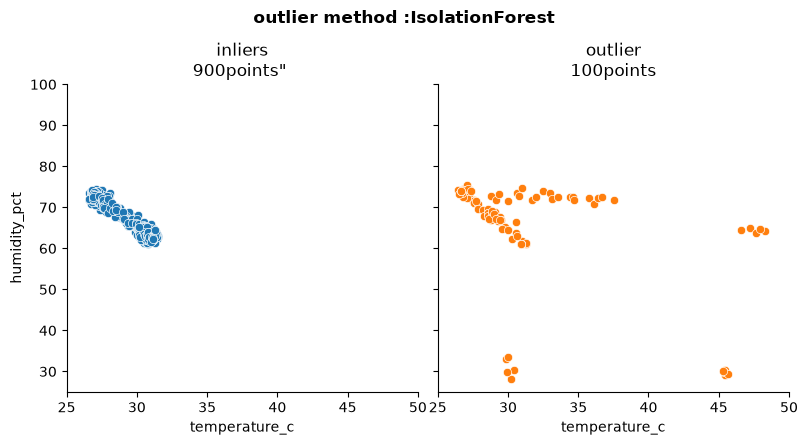

In [27]:
outlier_plot(df,"IsolationForest","temperature_c","humidity_pct")

multi features

In [18]:
anomaly_inputs=['humidity_pct','temperature_c','pressure_hpa']

In [19]:
model_IF=IsolationForest(contamination=0.1,random_state=42)
model_IF.fit(df[anomaly_inputs])
df['anomaly_scores']=model_IF.decision_function(df[anomaly_inputs])
df['anomaly']=model_IF.predict(df[anomaly_inputs])

outlier method:IsolationForest
number of anomalous values 100
number of non anomalous values 900
total number of values:1000


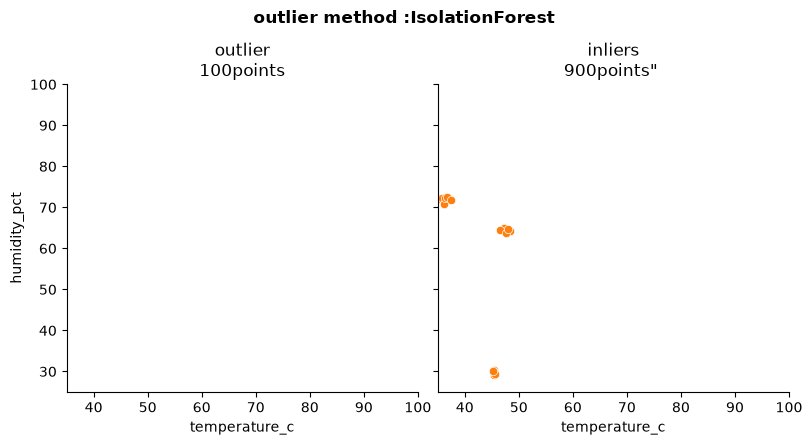

In [20]:
outlier_plot(df,'IsolationForest','temperature_c','humidity_pct',[35,100],[25,100],)

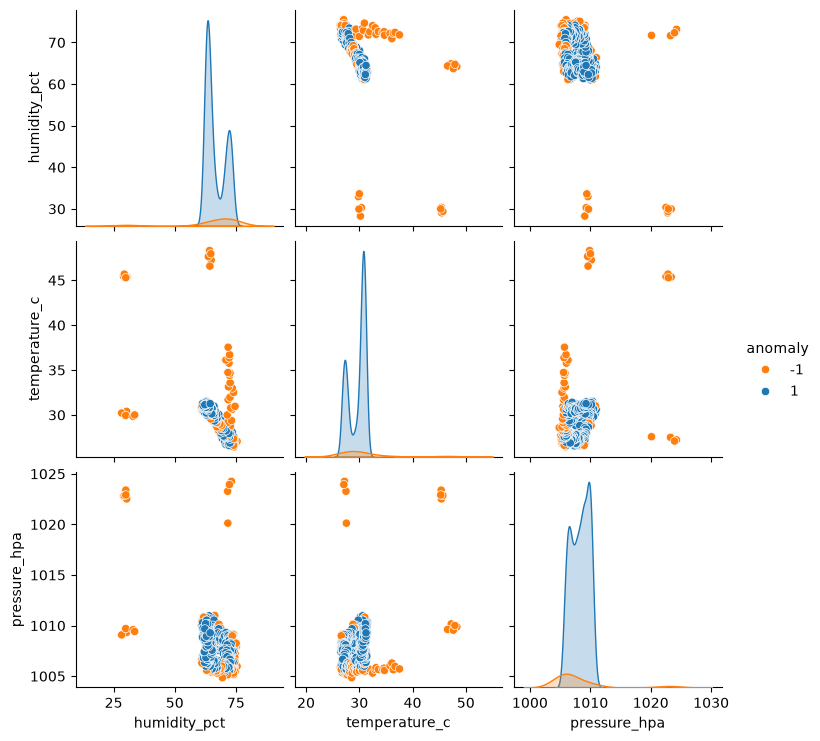

In [21]:
palette = ['#ff7f0e', '#1f77b4']
sns.pairplot(df,vars=anomaly_inputs,hue='anomaly',palette=palette)